# **TOPIC:** AES (Average Effect Size) — Ethnologue polygons

## **Author:** JM
### **Notes**: Follows the same pattern as `map_hansen_treecover_ethnologue.ipynb` (geopandas + matplotlib, quantile bins, truncated colormap, custom legend). Renders a choropleth of `aes_z` over the Ethnologue polygons.

`aes_z` is the rowmean of in-sample z-scored {bii, sh_treecover, sh_seasonwater_base}. It is built by [`code/analysis/export_aes_for_map.do`](../analysis/export_aes_for_map.do) and exported to `maps/aes_for_map.csv` (key: `id`).

In [9]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import mapclassify
from matplotlib.patches import Patch
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties

## - Setting paths and importing shapes

In [10]:
# Set base project path
base_path = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")

# Set file paths
poscol_path  = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
basemap_path = base_path / "maps" / "interim" / "World" / "world_dissolve_nolakes.shp"

aes_csv = base_path / "maps" / "aes_for_map.csv"

export_path = Path("C:/Users/juami/Dropbox/Overleaf/Nathan-Maps/plots")
export_path.mkdir(parents=True, exist_ok=True)

In [11]:
# Read the shapefiles
poscol_shape  = gpd.read_file(poscol_path)
basemap_shape = gpd.read_file(basemap_path)

print(poscol_shape.crs)
print(basemap_shape.crs)

EPSG:4326
EPSG:4326


### Merging AES values onto the Ethnologue polygons

In [12]:
# Load AES from Stata (export_aes_for_map.do) — key is lowercase `id`
aes_df = pd.read_csv(aes_csv)
aes_df = aes_df.rename(columns={"id": "ID"})

poscol_shape = poscol_shape.merge(
    aes_df[["ID", "aes_z"]],
    on="ID", how="left",
)

# Diagnostic: how many polygons have NaN (these get the "Missing" color)
print("Polygons with NaN per measure:")
for v in ["aes_z"]:
    print(f"  {v}: {poscol_shape[v].isna().sum()} of {len(poscol_shape)}")

poscol_shape[["ID", "aes_z"]].head()

Polygons with NaN per measure:
  aes_z: 52 of 7087


,ID,aes_z
0,RUS-RUS,0.112551
1,ENG-USA,-0.271899
2,POR-BRA,0.090634
3,ENG-AUS,-0.377630
4,CMN-CHN,-0.353375


## - Replicating the map

In [13]:
# Setting the color palette for the map
def truncate_colormap(cmap_name='Greens', minval=0.3, maxval=1.0, n=100):
    cmap = plt.get_cmap(cmap_name)
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'{cmap_name}_trunc', cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# Stronger Greens (skip the lightest 30%) — matches the other Ethnologue maps
strong_greens = truncate_colormap('Greens', 0.3, 1.0)

### -- Map: Average Effect Size (AES, z-score)

In [14]:
# Define the number of quantiles
num_quantiles = 5

# Create quantile bins and get the labels
poscol_shape['quantile_cat'], bins = pd.qcut(
    poscol_shape['aes_z'], q=num_quantiles,
    retbins=True, labels=False, duplicates='drop'
)

# Creating the labels for the legend
label_map = {
    i: f"{bins[i]:.2f} - {bins[i+1]:.2f}"
    for i in range(len(bins) - 1)
}

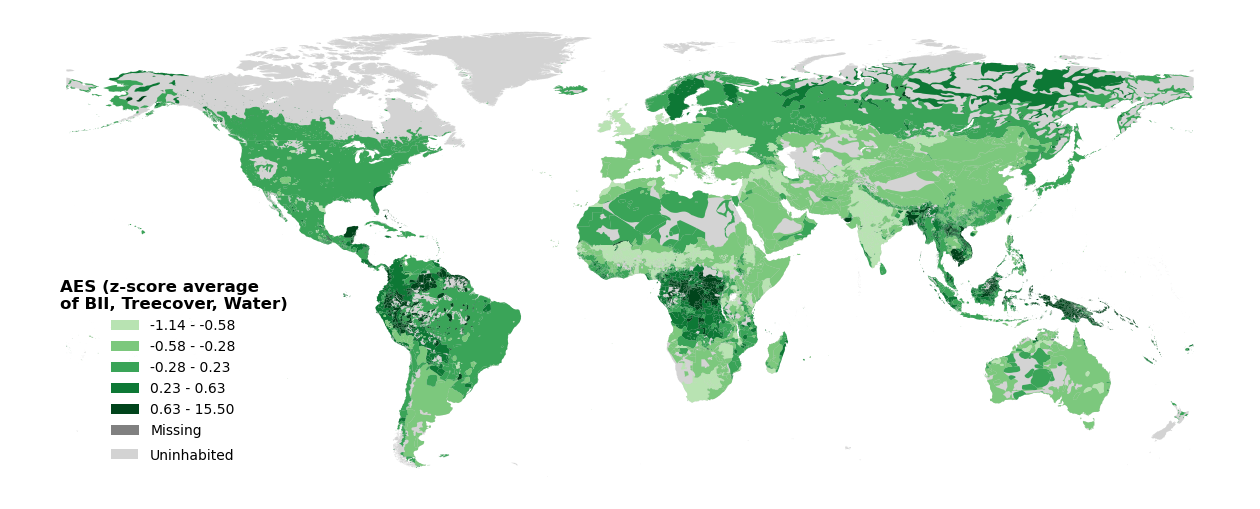

In [18]:
# Step 1: Extract unique categories (excluding NaNs)
categories = poscol_shape['quantile_cat'].dropna().unique()
categories = sorted(categories)

# Step 2: Sample colors from the custom colormap
n = len(categories)
category_colors = strong_greens(np.linspace(0, 1, n))
category_color_map = dict(zip(categories, category_colors))

# Step 3: Map the colors to a new column
poscol_shape['color'] = poscol_shape['quantile_cat'].map(category_color_map)

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 8), facecolor='white')

# Background
basemap_shape.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0
)

# Plot polygons with mapped colors
poscol_shape.plot(
    ax=ax,
    color=poscol_shape['color'].fillna('gray'),
    edgecolor='none',
    linewidth=0
)

# Custom legend
legend_elements = [
    Patch(facecolor=category_color_map[c], label=label_map.get(c, str(c)))
    for c in categories
]
legend_elements.append(Patch(facecolor='gray', label="Missing"))

# Show legend on the map
legend = ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.03, 0.1, 0.2, 0.2),
    frameon=False,
    title="AES (z-score average\nof BII, Treecover, Water)",
    title_fontproperties=FontProperties(weight='bold', size=12),
    prop=FontProperties(size=10)
)

# Uninhabited patch
uninhabited_patch = Patch(
    facecolor='lightgray',
    edgecolor='none',
    label='Uninhabited'
)
custom_legend = ax.legend(
    handles=[uninhabited_patch],
    loc='lower left',
    bbox_to_anchor=(0.071, 0.05, 0.2, 0.2),
    frameon=False,
    prop=FontProperties(size=10),
)
ax.add_artist(legend)

# Force same spatial extent
ax.set_aspect('equal', adjustable='box')
ax.set_axis_off()

# Save to PDF
plt.savefig(export_path / "AES_POSCOL.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()